In [41]:
import pandas as pd
import numpy as np
import math
from collections import Counter


In [42]:
data = {
    'Outlook': [
        'Sunny','Sunny','Sunny','Sunny',
        'Rain','Rain','Rain','Rain',
        'Cloudy','Cloudy','Cloudy','Cloudy',
        'Windy','Windy','Foggy','Foggy',
        'Sunny','Rain','Cloudy','Windy'
    ],

    'Temperature': [
        'Hot','Very_Hot','Warm','Mild',
        'Cool','Cold','Mild','Warm',
        'Mild','Warm','Cool','Cold',
        'Hot','Warm','Cool','Cold',
        'Mild','Cool','Warm','Hot'
    ],

    'Humidity': [
        'High','Very_High','High','Medium',
        'High','Medium','Low','Medium',
        'Low','Medium','Low','Medium',
        'High','Low','High','Medium',
        'Medium','High','Low','Medium'
    ],

    'Wind': [
        'Weak','Strong','Moderate','Weak',
        'Strong','Weak','Moderate','Strong',
        'Weak','Moderate','Strong','Weak',
        'Moderate','Strong','Weak','Moderate',
        'Strong','Weak','Moderate','Strong'
    ],

    'Pressure': [
        'High','Low','Medium','High',
        'Low','Medium','High','Low',
        'Medium','High','Low','Medium',
        'High','Low','Medium','High',
        'Low','Medium','High','Low'
    ],

    'Play_Outdoor': [
        'No','No','No','Yes',
        'Yes','No','Yes','Yes',
        'Yes','Yes','Yes','No',
        'No','Yes','No','No',
        'Yes','Yes','Yes','No'
    ]
}

df = pd.DataFrame(data)
df


,Outlook,Temperature,Humidity,Wind,Pressure,Play_Outdoor
0,Sunny,Hot,High,Weak,High,No
1,Sunny,Very_Hot,Very_High,Strong,Low,No
2,Sunny,Warm,High,Moderate,Medium,No
3,Sunny,Mild,Medium,Weak,High,Yes
4,Rain,Cool,High,Strong,Low,Yes
5,Rain,Cold,Medium,Weak,Medium,No
6,Rain,Mild,Low,Moderate,High,Yes
7,Rain,Warm,Medium,Strong,Low,Yes
8,Cloudy,Mild,Low,Weak,Medium,Yes
9,Cloudy,Warm,Medium,Moderate,High,Yes


In [43]:
def entropy(target_col):
    counts = Counter(target_col)
    total = len(target_col)
    ent = 0
    for count in counts.values():
        p = count / total
        ent -= p * math.log2(p)
    return ent

print("Entropy:", entropy(df['Play_Outdoor']))


Entropy: 0.9927744539878083


In [44]:
def information_gain(data, feature, target="Play_Outdoor"):
    total_entropy = entropy(data[target])
    values = data[feature].unique()
    weighted_entropy = 0

    for value in values:
        subset = data[data[feature] == value]
        weighted_entropy += (len(subset)/len(data)) * entropy(subset[target])

    return total_entropy - weighted_entropy


In [45]:
def id3(data, features, target="Play_Outdoor"):

    node = {}
    node['samples'] = len(data)
    node['entropy'] = entropy(data[target])

    # If pure node
    if len(data[target].unique()) == 1:
        node['label'] = data[target].iloc[0]
        return node

    # If no features left
    if len(features) == 0:
        node['label'] = data[target].mode()[0]
        return node

    gains = [information_gain(data, feature, target) for feature in features]
    best_feature = features[np.argmax(gains)]

    node['feature'] = best_feature
    node['children'] = {}

    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value]

        if subset.empty:
            node['children'][value] = {
                'label': data[target].mode()[0],
                'entropy': 0,
                'samples': 0
            }
        else:
            remaining_features = [f for f in features if f != best_feature]
            node['children'][value] = id3(subset, remaining_features, target)

    return node


In [46]:
features = list(df.columns[:-1])
tree = id3(df, features)
tree

{'samples': 20,
 'entropy': 0.9927744539878083,
 'feature': 'Temperature',
 'children': {'Hot': {'samples': 3, 'entropy': 0.0, 'label': 'No'},
  'Very_Hot': {'samples': 1, 'entropy': 0.0, 'label': 'No'},
  'Warm': {'samples': 5,
   'entropy': 0.7219280948873623,
   'feature': 'Outlook',
   'children': {'Sunny': {'samples': 1, 'entropy': 0.0, 'label': 'No'},
    'Rain': {'samples': 1, 'entropy': 0.0, 'label': 'Yes'},
    'Cloudy': {'samples': 2, 'entropy': 0.0, 'label': 'Yes'},
    'Windy': {'samples': 1, 'entropy': 0.0, 'label': 'Yes'}}},
  'Mild': {'samples': 4, 'entropy': 0.0, 'label': 'Yes'},
  'Cool': {'samples': 4,
   'entropy': 0.8112781244591328,
   'feature': 'Outlook',
   'children': {'Rain': {'samples': 2, 'entropy': 0.0, 'label': 'Yes'},
    'Cloudy': {'samples': 1, 'entropy': 0.0, 'label': 'Yes'},
    'Foggy': {'samples': 1, 'entropy': 0.0, 'label': 'No'}}},
  'Cold': {'samples': 3, 'entropy': 0.0, 'label': 'No'}}}

In [49]:
def get_tree_width(node):
    if 'label' in node:
        return 1
    return sum(get_tree_width(child) for child in node['children'].values())


In [50]:
import matplotlib.pyplot as plt

def draw_tree_balanced(node, x, y, x_min, x_max, y_step, ax):

    # Center position of this node
    x_center = (x_min + x_max) / 2

    # Leaf node
    if 'label' in node:
        text = f"{node['label']}\nEntropy={node['entropy']:.3f}\nSamples={node['samples']}"
        ax.text(x_center, y, text,
                ha='center',
                bbox=dict(boxstyle="round", facecolor="lightgreen"),
                fontsize=9)
        return

    # Decision node
    text = f"{node['feature']}\nEntropy={node['entropy']:.3f}\nSamples={node['samples']}"

    ax.text(x_center, y, text,
            ha='center',
            bbox=dict(boxstyle="round", facecolor="lightblue"),
            fontsize=10)

    # Draw children
    total_width = get_tree_width(node)
    current_x = x_min

    for value, child in node['children'].items():
        child_width = get_tree_width(child)
        child_x_min = current_x
        child_x_max = current_x + (x_max - x_min) * (child_width / total_width)
        child_x_center = (child_x_min + child_x_max) / 2

        # Draw branch line
        ax.plot([x_center, child_x_center], [y-0.03, y - y_step + 0.03])

        # Branch label
        ax.text((x_center + child_x_center)/2, y - y_step/2,
                value, fontsize=8)

        # Recursive draw
        draw_tree_balanced(child,
                           child_x_center,
                           y - y_step,
                           child_x_min,
                           child_x_max,
                           y_step,
                           ax)

        current_x = child_x_max


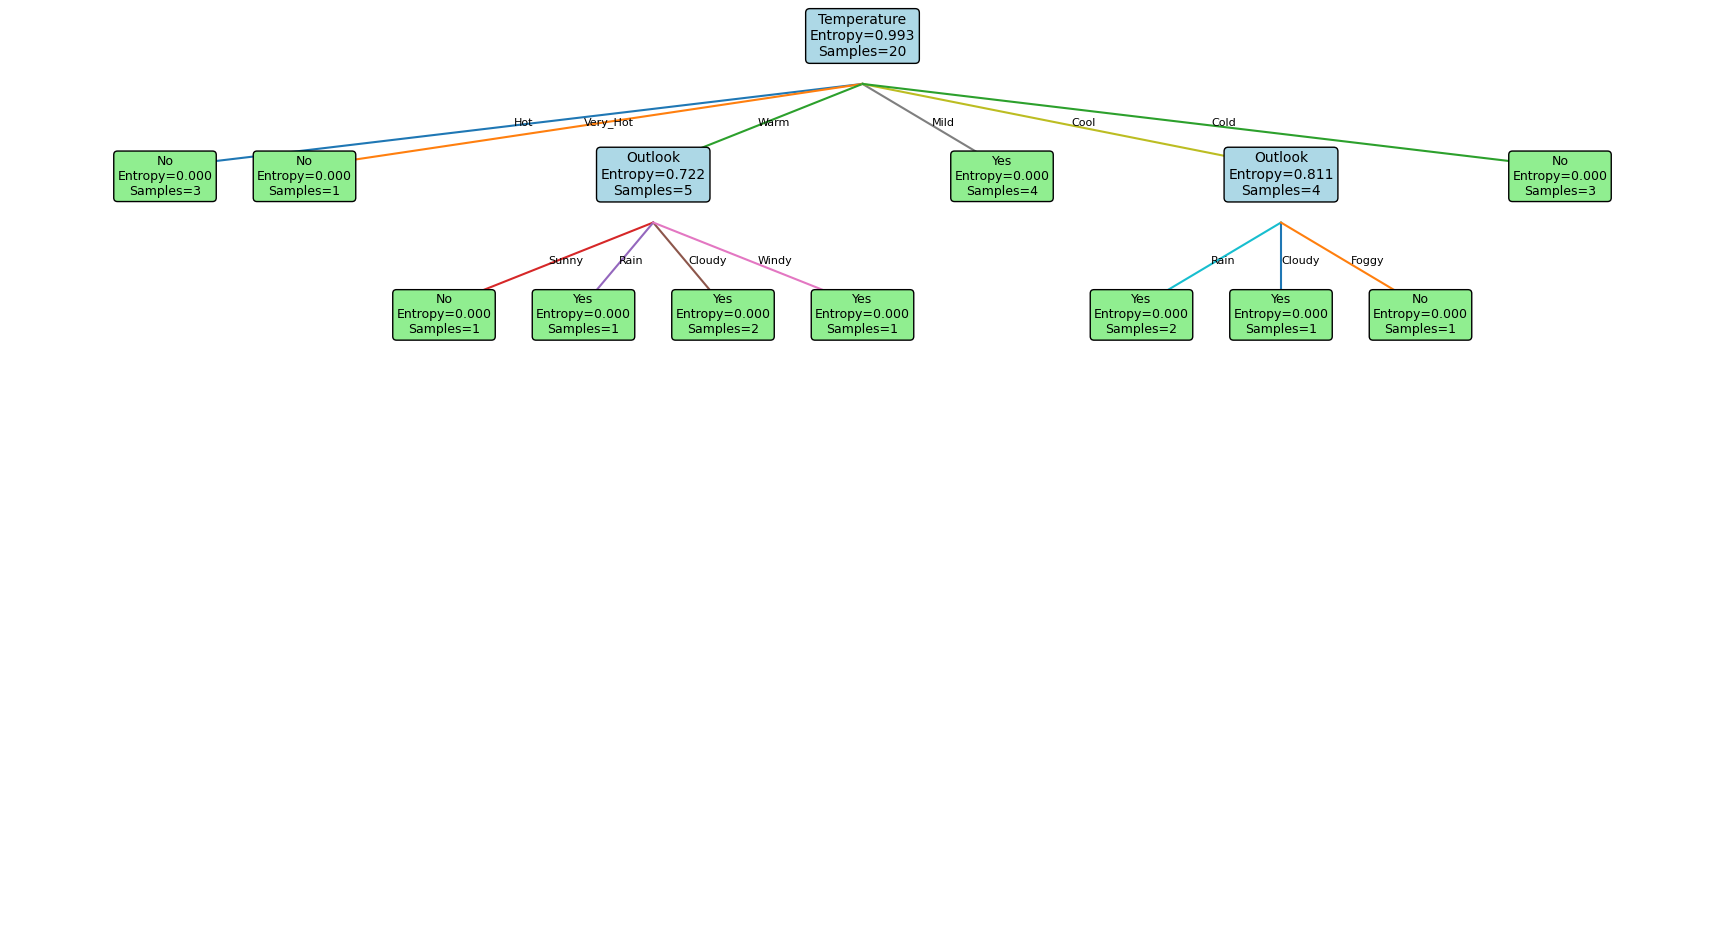

In [51]:
fig, ax = plt.subplots(figsize=(22,12))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis("off")

draw_tree_balanced(tree,
                   x=0.5,
                   y=0.95,
                   x_min=0.05,
                   x_max=0.95,
                   y_step=0.15,
                   ax=ax)

plt.show()
